# 03 · Activation Functions: advantages and limitations
NumPy for the model · matplotlib for graphs · Runs on Google Colab

1. All activations and their slopes
2. Same XOR network with each activation
3. Limitations, one experiment each
4. Summary

## Data and plot helper (same XOR-type data as the previous notebook)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)
corners = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

def make_gate_data(gate, n=50, spread=0.15):
    X = np.vstack([c + rng.normal(0, spread, (n, 2)) for c in corners])
    y = np.repeat(gate, n)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

def split(X, y, test_ratio=0.2):
    n_test = int(len(X) * test_ratio)
    return X[n_test:], X[:n_test], y[n_test:], y[:n_test]

def add_x0(X):
    return np.hstack([-np.ones((len(X), 1)), X])                  # x0 = -1, so w0 is the threshold

X, y = make_gate_data([0, 1, 1, 0])
Xtr, Xte, ytr, yte = split(X, y)
Xtr0, Xte0 = add_x0(Xtr), add_x0(Xte)

g = np.linspace(-0.6, 1.6, 200)
G1, G2 = np.meshgrid(g, g)
GRID = np.c_[G1.ravel(), G2.ravel()]

def plot_region(ax, predict, X, y, title):
    ax.contourf(G1, G2, predict(GRID).reshape(G1.shape), levels=[-0.5, 0.5, 1.5], colors=["#f6d5d5", "#d5efd5"])
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="green", edgecolors="k", s=25)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="red", marker="X", edgecolors="k", s=25)
    ax.set(xlim=(-0.6, 1.6), ylim=(-0.6, 1.6), xlabel="x1", ylabel="x2", title=title, aspect="equal")

---
# Part 1: all activations and their slopes

| Name | $f(s)$ | Slope $f'(s)$ | Output range |
|---|---|---|---|
| step | 1 if $s \ge 0$ else 0 | 0 | {0, 1} |
| linear | $s$ | 1 | any |
| sigmoid | $\frac{1}{1+e^{-s}}$ | $f(1-f)$, max 0.25 | (0, 1) |
| tanh | $\tanh(s)$ | $1 - f^2$, max 1 | (−1, 1) |
| relu | $\max(0, s)$ | 1 if $s>0$ else 0 | [0, ∞) |
| leaky relu | $s$ if $s>0$ else $0.01s$ | 1 or 0.01 | any |

In [2]:
ACT = {
    "step":       (lambda s: (s >= 0).astype(float),     lambda s: np.zeros_like(s)),
    "linear":     (lambda s: s,                            lambda s: np.ones_like(s)),
    "sigmoid":    (lambda s: 1 / (1 + np.exp(-s)),         lambda s: np.exp(-s) / (1 + np.exp(-s)) ** 2),
    "tanh":       (np.tanh,                                lambda s: 1 - np.tanh(s) ** 2),
    "relu":       (lambda s: np.maximum(0, s),             lambda s: (s > 0).astype(float)),
    "leaky relu": (lambda s: np.where(s > 0, s, 0.01 * s), lambda s: np.where(s > 0, 1.0, 0.01)),
}
sigmoid, d_sigmoid = ACT["sigmoid"]

s = np.array([-5.0, -1.0, 0.0, 1.0, 5.0])
print(f"{'':>10}   value at s = {s}            slope at s = {s}")
for name, (f, df) in ACT.items():
    print(f"{name:>10} | {np.round(f(s), 3)} | {np.round(df(s), 3)}")

             value at s = [-5. -1.  0.  1.  5.]            slope at s = [-5. -1.  0.  1.  5.]
      step | [0. 0. 1. 1. 1.] | [0. 0. 0. 0. 0.]
    linear | [-5. -1.  0.  1.  5.] | [1. 1. 1. 1. 1.]
   sigmoid | [0.007 0.269 0.5   0.731 0.993] | [0.007 0.197 0.25  0.197 0.007]
      tanh | [-1.    -0.762  0.     0.762  1.   ] | [0.   0.42 1.   0.42 0.  ]
      relu | [0. 0. 0. 1. 5.] | [0. 0. 0. 1. 1.]
leaky relu | [-0.05 -0.01  0.    1.    5.  ] | [0.01 0.01 0.01 1.   1.  ]


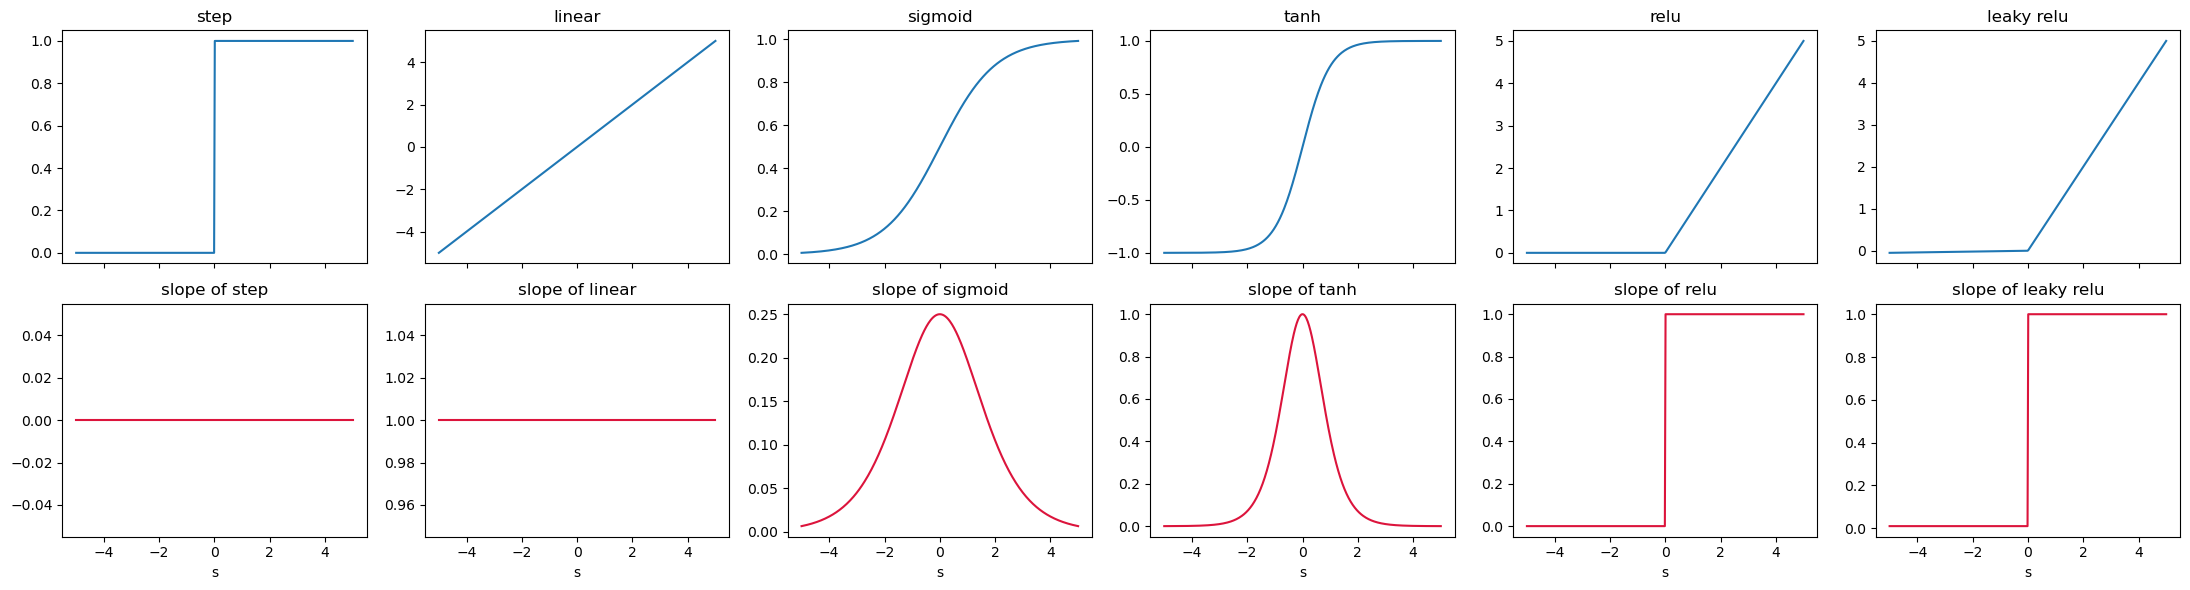

In [3]:
zs = np.linspace(-5, 5, 400)
fig, axes = plt.subplots(2, len(ACT), figsize=(22, 6), sharex=True)
for k, (name, (f, df)) in enumerate(ACT.items()):
    axes[0, k].plot(zs, f(zs))
    axes[0, k].set_title(name)
    axes[1, k].plot(zs, df(zs), color="crimson")
    axes[1, k].set_title(f"slope of {name}")
    axes[1, k].set_xlabel("s")
plt.tight_layout()
plt.show()

---
# Part 2: the same XOR network with each hidden activation

Network 2 ➜ H ➜ 1, hidden activation from `ACT`, output sigmoid. Same delta rule as the previous notebook.

In [4]:
def new_net(hidden, act, scale=1.0):
    return {"act": act,
            "W1": rng.uniform(-scale, scale, (3, hidden)),
            "W2": rng.uniform(-scale, scale, hidden + 1)}

def mlp_forward_pass(x, net):
    f = ACT[net["act"]][0]
    s1 = x @ net["W1"]
    h = np.r_[-1, f(s1)]                                          # h0 = -1 for the output threshold
    s2 = h @ net["W2"]
    return sigmoid(s2), (s1, h, s2)

def compute_error(y, y_hat):
    return y - y_hat

def mlp_backward_pass(net, x, error, cache, lr):
    s1, h, s2 = cache
    df = ACT[net["act"]][1]
    delta_out = error * d_sigmoid(s2)
    delta_hidden = delta_out * net["W2"][1:] * df(s1)             # error passed back through the slope
    dW2 = -delta_out * h
    dW1 = -np.outer(x, delta_hidden)
    return {"act": net["act"], "W1": net["W1"] - lr * dW1, "W2": net["W2"] - lr * dW2}

def mlp_predict(P, net):
    f = ACT[net["act"]][0]
    H = np.hstack([-np.ones((len(P), 1)), f(add_x0(P) @ net["W1"])])
    return (sigmoid(H @ net["W2"]) >= 0.5).astype(int)

def mlp_accuracy(X0, y, net):
    return 100 * (mlp_predict(X0[:, 1:], net) == y).mean()


def mlp_train(X, y, net, lr, epochs):
    losses, first_100 = [], None                                  # first_100 = first epoch with 100% train accuracy
    for epoch in range(1, epochs + 1):
        errors = []
        for x, target in zip(X, y):
            y_hat, cache = mlp_forward_pass(x, net)
            error = compute_error(target, y_hat)
            net = mlp_backward_pass(net, x, error, cache, lr)
            errors.append(error)
        losses.append(np.mean(np.square(errors)))
        if first_100 is None and mlp_accuracy(X, y, net) == 100:
            first_100 = epoch
    return net, losses, first_100

## 20 random starts per activation (4 hidden neurons, η = 0.5, 100 epochs)

In [5]:
results = {}
print(f"{'activation':>10} | {'solved (test ≥ 95%)':>19} | {'avg test acc':>12} | {'avg epochs to 100% train':>24}")
print("-" * 76)
for act in ACT:
    runs = [mlp_train(Xtr0, ytr, new_net(4, act), 0.5, 100) for _ in range(20)]
    accs = [mlp_accuracy(Xte0, yte, net) for net, _, _ in runs]
    reached = [e for _, _, e in runs if e is not None]
    results[act] = runs
    avg_ep = f"{np.mean(reached):.0f}" if reached else "-"
    print(f"{act:>10} | {sum(a >= 95 for a in accs):>13}/20 | {np.mean(accs):11.1f}% | {avg_ep:>24}")

activation | solved (test ≥ 95%) | avg test acc | avg epochs to 100% train
----------------------------------------------------------------------------
      step |             1/20 |        71.1% |                        -
    linear |             0/20 |        47.5% |                        -
   sigmoid |            20/20 |       100.0% |                       27
      tanh |            20/20 |        99.5% |                        8
      relu |            17/20 |        95.0% |                        9
leaky relu |            19/20 |        97.2% |                       16


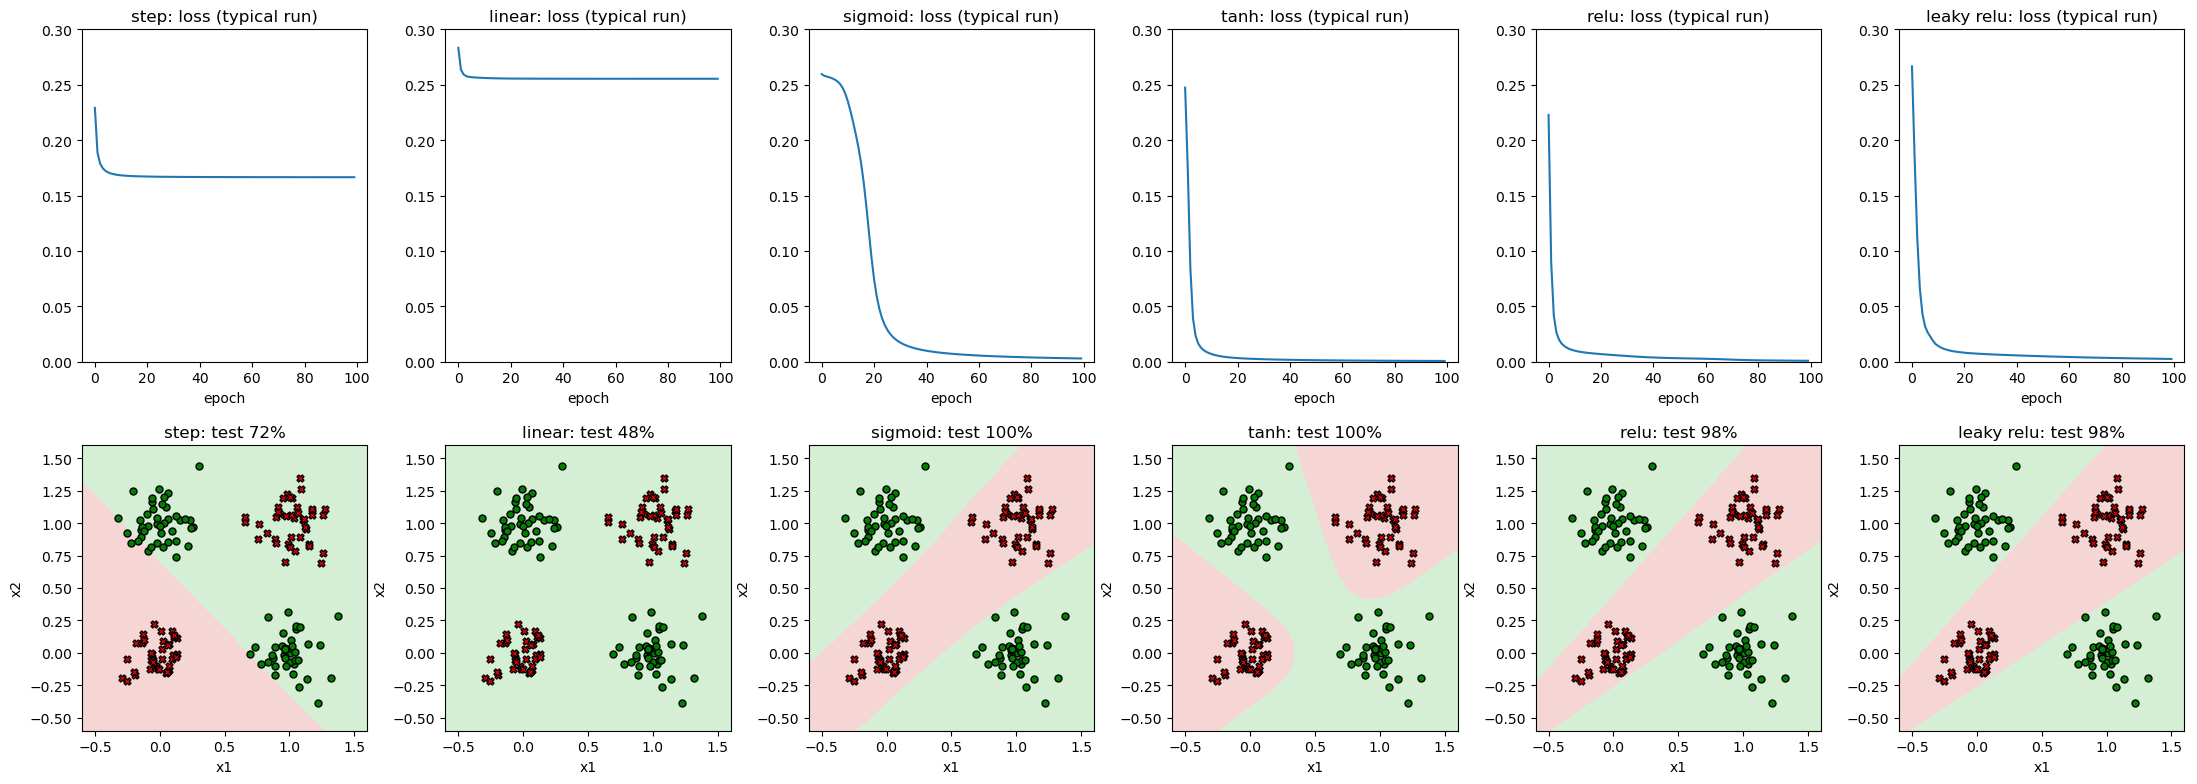

In [6]:
fig, axes = plt.subplots(2, len(ACT), figsize=(22, 8))
for k, act in enumerate(ACT):
    typical = sorted(results[act], key=lambda r: mlp_accuracy(Xte0, yte, r[0]))[len(results[act]) // 2]   # median run
    axes[0, k].plot(typical[1])
    axes[0, k].set(title=f"{act}: loss (typical run)", xlabel="epoch", ylim=(0, 0.3))
    plot_region(axes[1, k], lambda P: mlp_predict(P, typical[0]), Xtr, ytr, f"{act}: test {mlp_accuracy(Xte0, yte, typical[0]):.0f}%")
plt.tight_layout()
plt.show()

- **step**: slope 0 ➜ hidden layer never learns (an occasional success is just lucky random hidden lines)
- **linear**: two linear layers = one line ➜ can't bend around XOR
- **sigmoid / tanh / relu / leaky relu**: non-linear **and** have a slope ➜ can learn XOR

---
# Part 3: limitations, one experiment each
## 3a. Linear collapses to a single line
Two linear layers: $(x W_1) W_2 = x (W_1 W_2)$ — the same as one neuron.

In [7]:
lin_net = new_net(4, "linear")
x_demo = Xtr0[:3]
two_layers = np.hstack([-np.ones((3, 1)), x_demo @ lin_net["W1"]]) @ lin_net["W2"]
W_single = lin_net["W1"] @ lin_net["W2"][1:]                       # merge the two layers into one weight vector
one_layer = x_demo @ W_single - lin_net["W2"][0]
print("s at the output, two linear layers:", two_layers)
print("s at the output, one merged neuron:", one_layer)

s at the output, two linear layers: [ 0.0582 -0.4    -0.4309]
s at the output, one merged neuron: [ 0.0582 -0.4    -0.4309]


## 3b. Sigmoid and tanh saturate: big inputs ➜ slope ≈ 0 ➜ learning stalls
Same network, starting weights ±1 vs ±10 vs ±30 (10 random starts each, 100 epochs).

s =  0: slope of sigmoid = 0.25000 | slope of tanh = 1.00000
s =  2: slope of sigmoid = 0.10499 | slope of tanh = 0.07065
s =  5: slope of sigmoid = 0.00665 | slope of tanh = 0.00018
s = 10: slope of sigmoid = 0.00005 | slope of tanh = 0.00000

activation | start weights | avg hidden slope at start | solved | avg loss after 100 epochs
--------------------------------------------------------------------------------------------
   sigmoid |            ±1 |                    0.2131 |  10/10 |                    0.0043
   sigmoid |           ±10 |                    0.0359 |   4/10 |                    0.2134
   sigmoid |           ±30 |                    0.0184 |   0/10 |                    0.3950
      tanh |            ±1 |                    0.6087 |  10/10 |                    0.0004
      tanh |           ±10 |                    0.0619 |   1/10 |                    0.3217
      tanh |           ±30 |                    0.0353 |   1/10 |                    0.2853


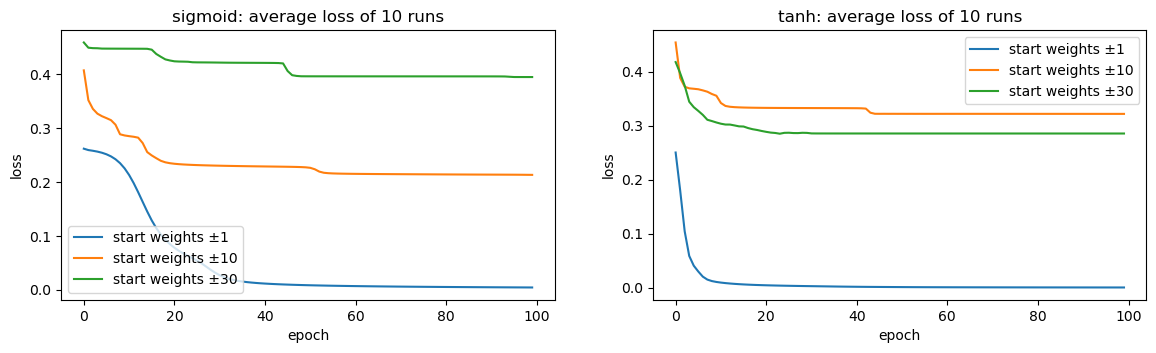

In [8]:
for s_val in [0, 2, 5, 10]:
    print(f"s = {s_val:>2}: slope of sigmoid = {d_sigmoid(np.array(s_val)):.5f} | slope of tanh = {ACT['tanh'][1](np.array(s_val)):.5f}")

print(f"\n{'activation':>10} | {'start weights':>13} | {'avg hidden slope at start':>25} | {'solved':>6} | {'avg loss after 100 epochs':>25}")
print("-" * 92)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, act in zip(axes, ["sigmoid", "tanh"]):
    for scale in [1, 10, 30]:
        starts = [new_net(4, act, scale) for _ in range(10)]
        start_slope = np.mean([ACT[act][1](Xtr0 @ n["W1"]).mean() for n in starts])
        runs = [mlp_train(Xtr0, ytr, n, 0.5, 100) for n in starts]
        solved = sum(mlp_accuracy(Xte0, yte, net) >= 95 for net, _, _ in runs)
        avg_loss = np.mean([losses for _, losses, _ in runs], axis=0)
        print(f"{act:>10} | {'±' + str(scale):>13} | {start_slope:25.4f} | {solved:>3}/10 | {avg_loss[-1]:25.4f}")
        ax.plot(avg_loss, label=f"start weights ±{scale}")
    ax.set(title=f"{act}: average loss of 10 runs", xlabel="epoch", ylabel="loss")
    ax.legend()
plt.show()

## 3c. ReLU can "die": if $s < 0$ for every input, its slope is 0 forever
Force hidden neuron 1 to have $s = -5 - x_1 - x_2 < 0$ for every input, train 20 epochs, and compare its weights.

In [9]:
dead_start = new_net(4, "relu")
dead_start["W1"][:, 0] = [5.0, -1.0, -1.0]                       # [w0, w1, w2] with x0 = -1 -> s = -5 - x1 - x2

for act in ["relu", "leaky relu"]:
    net0 = {"act": act, "W1": dead_start["W1"].copy(), "W2": dead_start["W2"].copy()}
    net, _, _ = mlp_train(Xtr0, ytr, net0, 0.5, 20)
    print(f"{act:>10}: neuron 1 weights {net0['W1'][:, 0]} -> {net['W1'][:, 0]}")

dead_runs = sum(((Xtr0 @ net["W1"]) <= 0).all(axis=0).any() for net, _, _ in results["relu"])
print(f"\nIn Part 2, relu runs that ended with at least one dead neuron: {dead_runs}/20")

      relu: neuron 1 weights [ 5. -1. -1.] -> [ 5. -1. -1.]
leaky relu: neuron 1 weights [ 5. -1. -1.] -> [ 4.9994 -1.0153 -1.4647]

In Part 2, relu runs that ended with at least one dead neuron: 13/20


## 3d. Sigmoid's slope is at most 0.25, tanh's is 1
Every layer multiplies the error by the slope, so sigmoid passes back at most a quarter of it. Compare the speed in the Part 2 table (avg epochs to 100%).

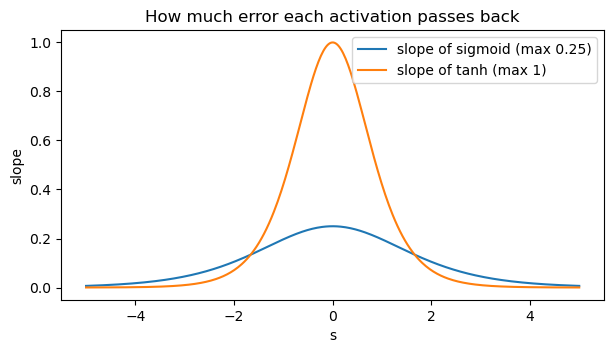

In [10]:
s_line = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(s_line, d_sigmoid(s_line), label="slope of sigmoid (max 0.25)")
ax.plot(s_line, ACT["tanh"][1](s_line), label="slope of tanh (max 1)")
ax.set(xlabel="s", ylabel="slope", title="How much error each activation passes back")
ax.legend()
plt.show()

---
# Part 4: summary

| Activation | Advantage | Limitation |
|---|---|---|
| step | simple yes/no output | slope 0 ➜ hidden layers can't learn |
| linear | slope always 1 | layers collapse into one line ➜ can't solve XOR |
| sigmoid | smooth, output in (0, 1) reads like a probability | saturates (slope ≈ 0 for large \|s\|), max slope 0.25 ➜ slow |
| tanh | output centred on 0, max slope 1 ➜ usually faster than sigmoid | still saturates for large \|s\| |
| relu | no saturation for $s > 0$, very cheap | dead neurons (slope 0 for $s < 0$) |
| leaky relu | fixes dead neurons with a small negative slope | one more choice (the 0.01) |

**Output layer:** for a yes/no answer we used sigmoid (one output between 0 and 1). For **several classes** we need one output per class and a way to turn them into probabilities that add up to 1 ➜ next notebook: **multiclass**.